### 딥러닝 발전의 흐름
1. CNN
2. RNN $\to$ LSTM $\to$ Transformer
3. GAN
4. Transfer Learning $\to$ GPT

## CNN(합성곱 신경망)
- CNN(Convolutional Neural Network)
  - 컴퓨터 비전 문제에 적합한 아키텍처

### 전통적인 방식
- 기존 컴퓨터 비전 방식
  - 미리 정해진 합성곱 커널(필터, 마스크)을 사용하여 원하는 형태의 패턴 추출
- 소벨 필터 적용 사례: 경계 검출 $\to$ 경계라는 특징(feature) 정보 추출

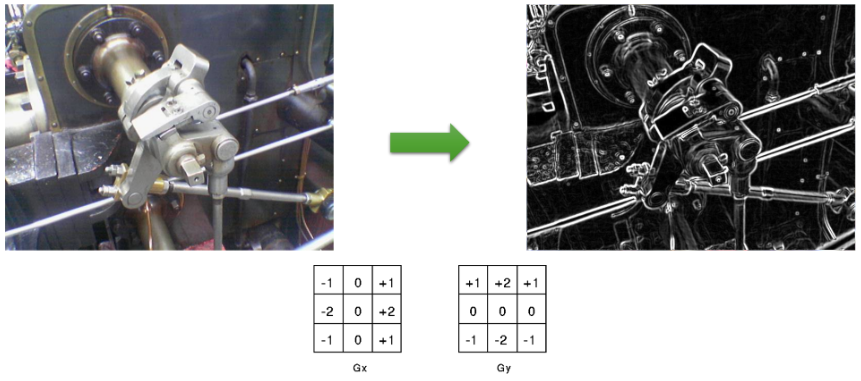

### 합성곱 연산
- $k_(1,1)$부터 $k_(3,3)$으로 이루어진 커널과 이미지의 각 위치와 곱셈 연산을 한 후, 전부 더한 결과가 $y_(1,1)$이 됨

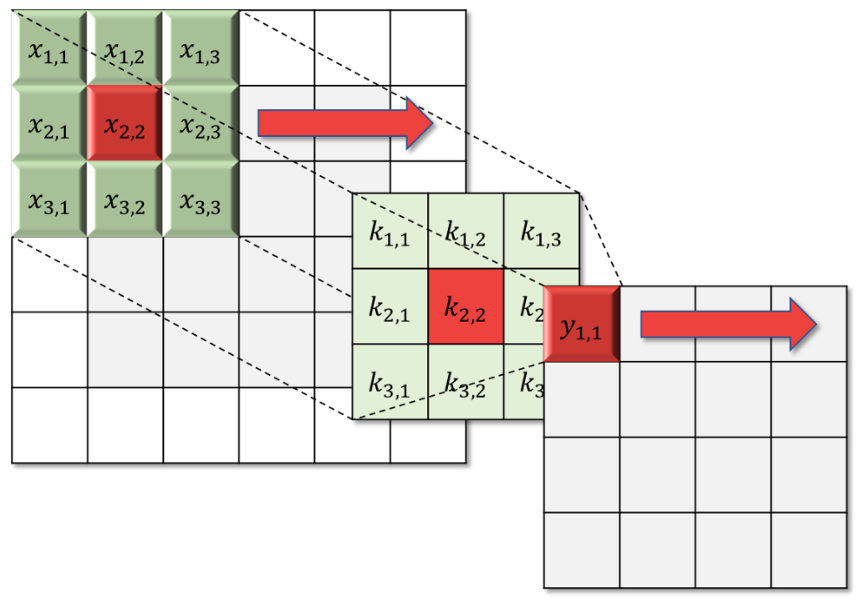
- 주의할 점
  - 입력이(6x6) 행렬이었는데 출력은 (4x4) 행렬로 줄어듬
- 합성곱 커널을 적용할 겨웅의 기본적인 형태
  - 출력은 입력에서 상하좌우 한 줄 씩 줄어듬

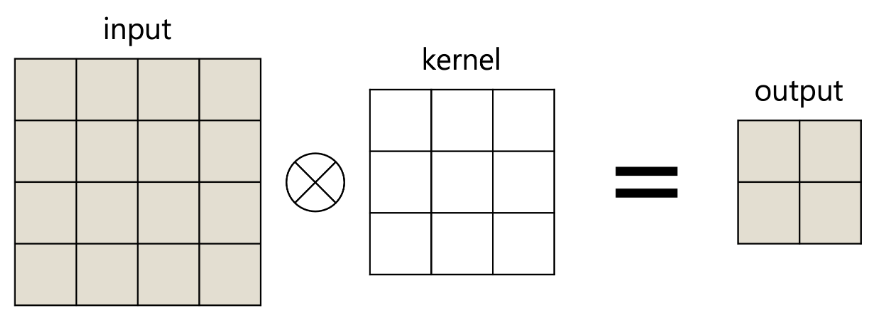


- 입력과 같은 크기의 출력을 가지려면?
  - 입력의 상하좌우에 패딩을 둘러주고 합성곱 연산을 함

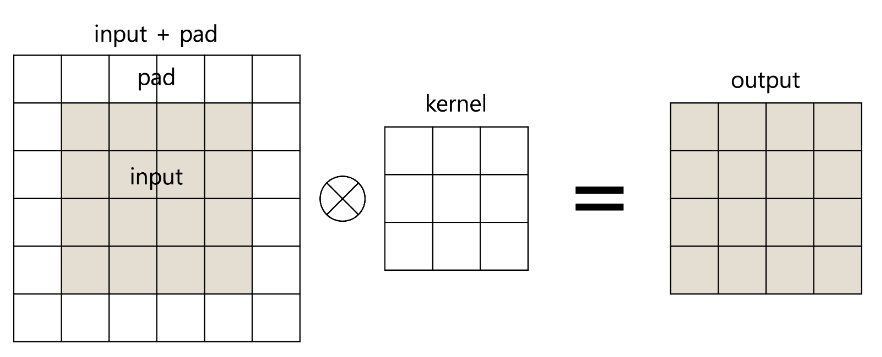

- 커널의 크기가 (5x5)라면?
  - 커널 중심에서 상하좌우로 2줄씩 둘어듬
  - 즉, 커너르이 중심점 하나를 제외한 크기만큼 줄어듬
- 출력의 크기(y_height, y_width)
  - $y_height = x_height - k_height + 1$
  - $y_width = x_width - k_width + 1$
- 입력과 같은 크기의 출력을 가지기 위해 패딩을 넣으려면 $p = \displaystyle\frac{k-1}{2}$만큼 추가해야 함
- 패딩을 추가한 출력의 크기
  - $y_height = x_height + 2 \times k_height + 1$
  - $y_width = x_width + 2 \times k_width + 1$

### 패턴 추출의 원리
- 숫자 "2"의 패턴 추출
  - 대각선과 가로 선 패턴의 커널 적용

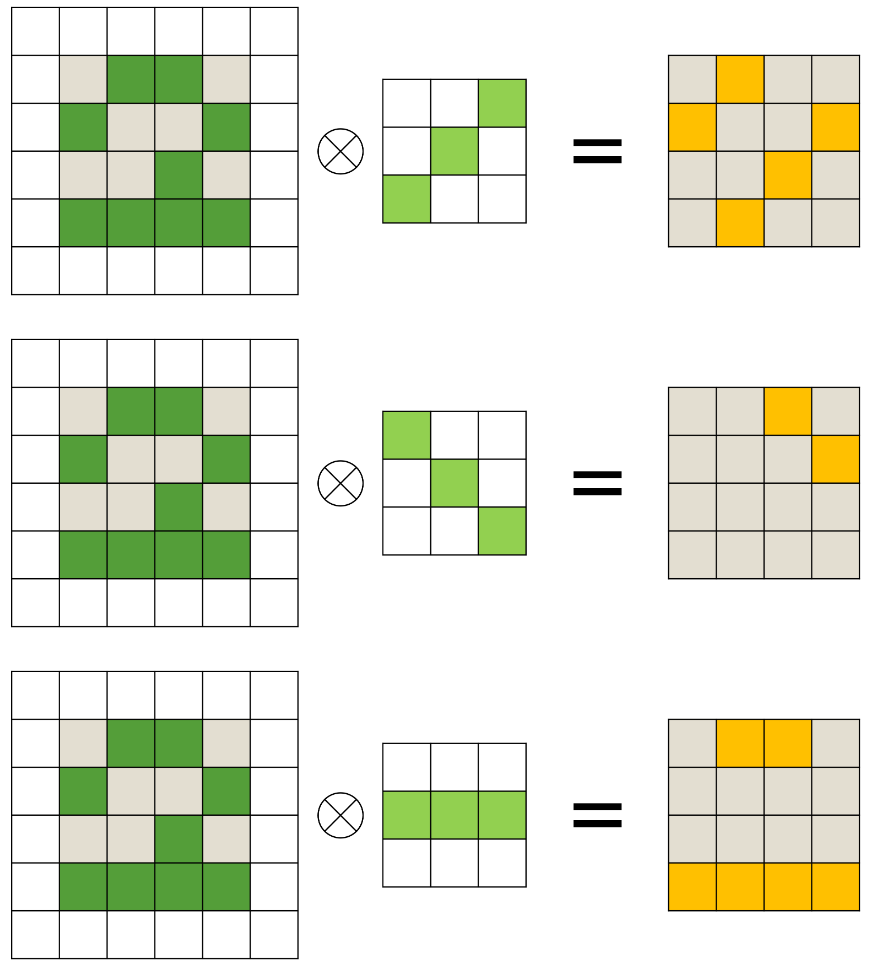
- 겹쳐진 개수가 많으면 많을수록 값이 커짐(큰 값: 노란색)
- 전통적인 머신러닝
  - 위 예와 같은 가정을 통해 미리 선정한 합성곱 커널을 사용하여 패턴 추출
- 딥러닝
  - 모델의 출력 $\hat y$와 목표값 y가 같아지도록 패턴을 추출할 수 있는 커널을 자동으로 학습
  - CNN에서는 합성곱 계층을 사용하여 커널을 학습함    

### 채널
- 입력 채널
  - 특징을 추출하기 위한 입력이 여러 종류일 때 이것을 입력 채널이라고 함
- 출력 채널
  - 여러 가지 특징의 패턴을 동시에 추출하고 싶을 때 여러 개의 커널을 적용하게 되는데, 이 커널의 수를 출력 채널이라고 함

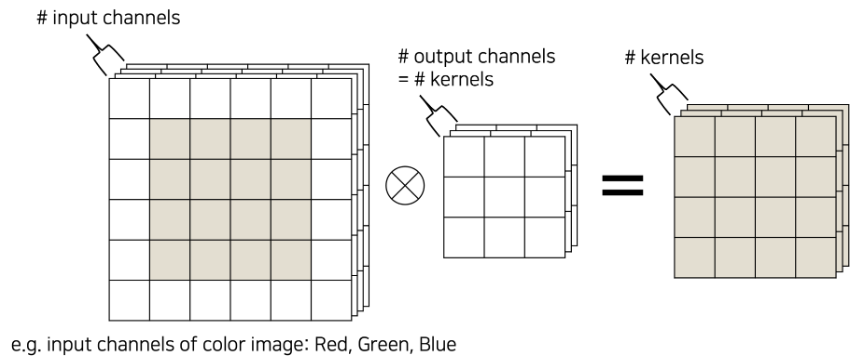

### 계층 입출력 텐서 형태
- 합성곱 계층의 입출력 텐서(패딩 추가)

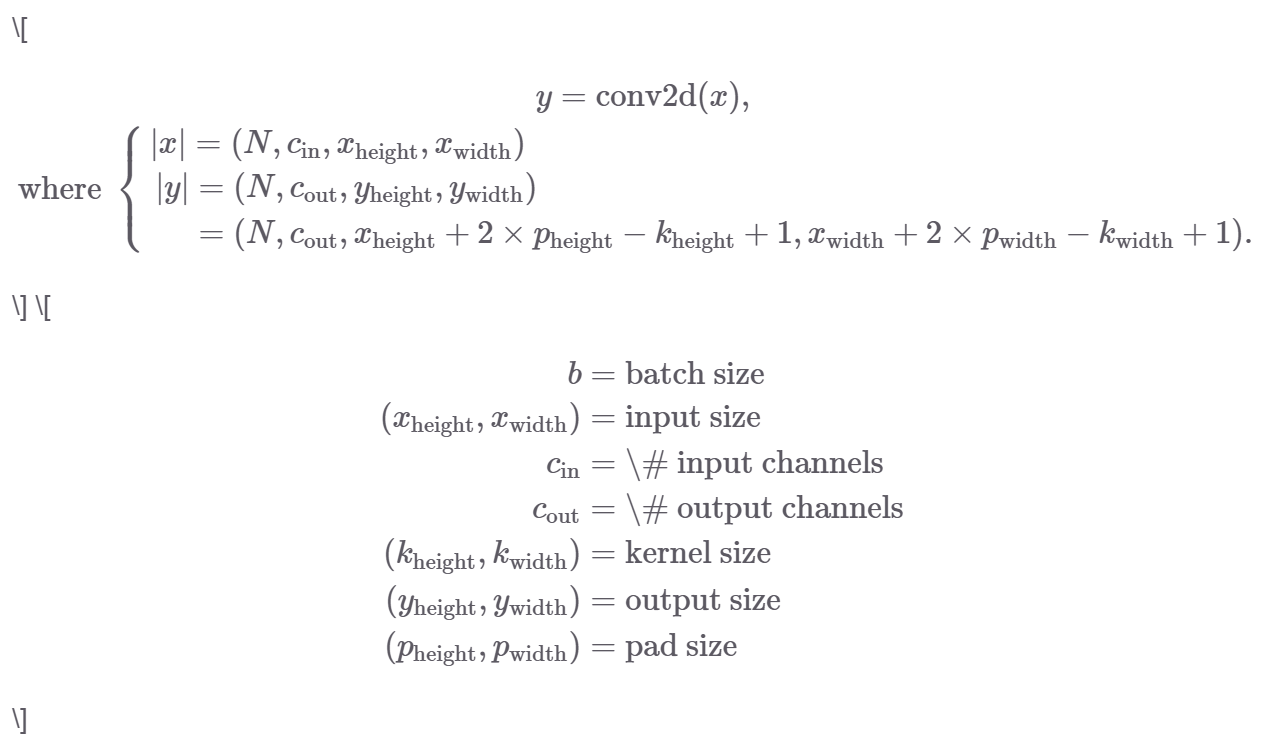

### 합성곱 계층의 특징과 장단점
- 선형 계층
  - 입력 벡터의 각 차원은 별개의 의미를 가진 특징임
  - 입력 데이터의 자리를 미렬 쓰거나 바꿔거나 하면 데이터의 의미를 일어버림
    - 키가 들어갈 위치에 몸무게 값을 넣으면 데이터의 의미가 없음
- 합성곱 계층
  - 이미지는 샘플의 픽셀이 약간씩 이동되거나 픽셀의 값이 약간 달라지더라도 인식하는데 문제가 없어야 함
  - 합성곱 계층은 이미지 데이터의 특징에 맞게 이런 변화에도 정상적으로 학습이 가능한 구조임
- 선형 계층
  - 입출력 벡터의 크기가 정해지면 내부 가중치 파라미터의 크기가 정해짐
- 합성곱 계층
  - 입출력 벡터의 크기와 상관없이 내부 커널의 크기에 따라 가중치 파라미터의 크기가 정해짐
  - 선형 계층보다 훨씬 적은 수의 파라미터를 가짐
  - $\to$ 속도, 메모리 측면에서 이득
  - $\to$ 최저고하 난이도가 낮아짐
- 합성곱 계층의 단점
  - 입출력 크기가 고정되어 있지 않기 때문에 직관적으로 확인하기 어려움
  - 입출력 크기를 계산하는 복잡한 수식 필요
  - $\to$ 신경망 구현 난이도가 높아짐

## 맥스 풀링과 스트라이드 기법
- 일반적인 심층신경망: 고차원 공간 $\to$ 저차원 공간(featrue의 개수를 줄임)
- 합성곱 계층의 일반적인 형태: 3 x 3 kernel + 1 padding $\to$ 차원의 크기는 변하지 않음
- 차원 크기 축소(다운샘플링)를 위한 기법 필요 $\to$ 맥스 풀링과 스트라이드

### 맥스 풀링
- 주어진 커널 범위 안에서 최대값 출력
- (2x2) 커널인 경우, 가로, 세로 절반 크기로 줄어듬
- 합성곱의 결과에서 값이 큰 것
  - 샘플 이미지의 해당 부분에서 커널의 패턴과 비슷한 패턴을 가지고 있다는 뜻
- 합성곱의 결과물 중에서 맥스 풀링을 통해서 큰 값을 남긴다는 것
  - 합성곱 계층의 커널의 패턴 정보를 강하게 남긴다는 의미가 됨

- 양을 줄이기 위해서 사용하는 기법
- 크기를 줄이는 데에 문제가 없음
  - 4개 중 가장 큰 값을 뽑음(feture가 가장 많이 들어가 있음) $\to$ 영향이 없는 것은 아니지만 의미가 있는 값을 이미 뽑았기 때문
 
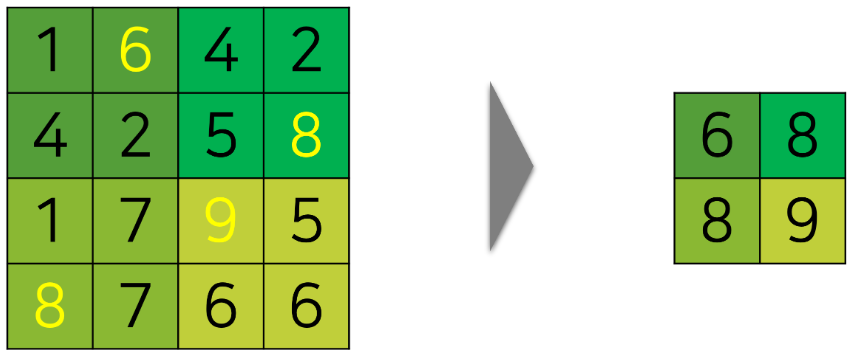

### 스트라이드
- 커널을 적용할 때 성큼성큼 칸을 건너뛰어 적용되도록 하는 기법
- 확률에 의존함
- 스트라이드가 가로/세로 2칸일 경우
  - ($S_height, S_width) = (2,2)
 
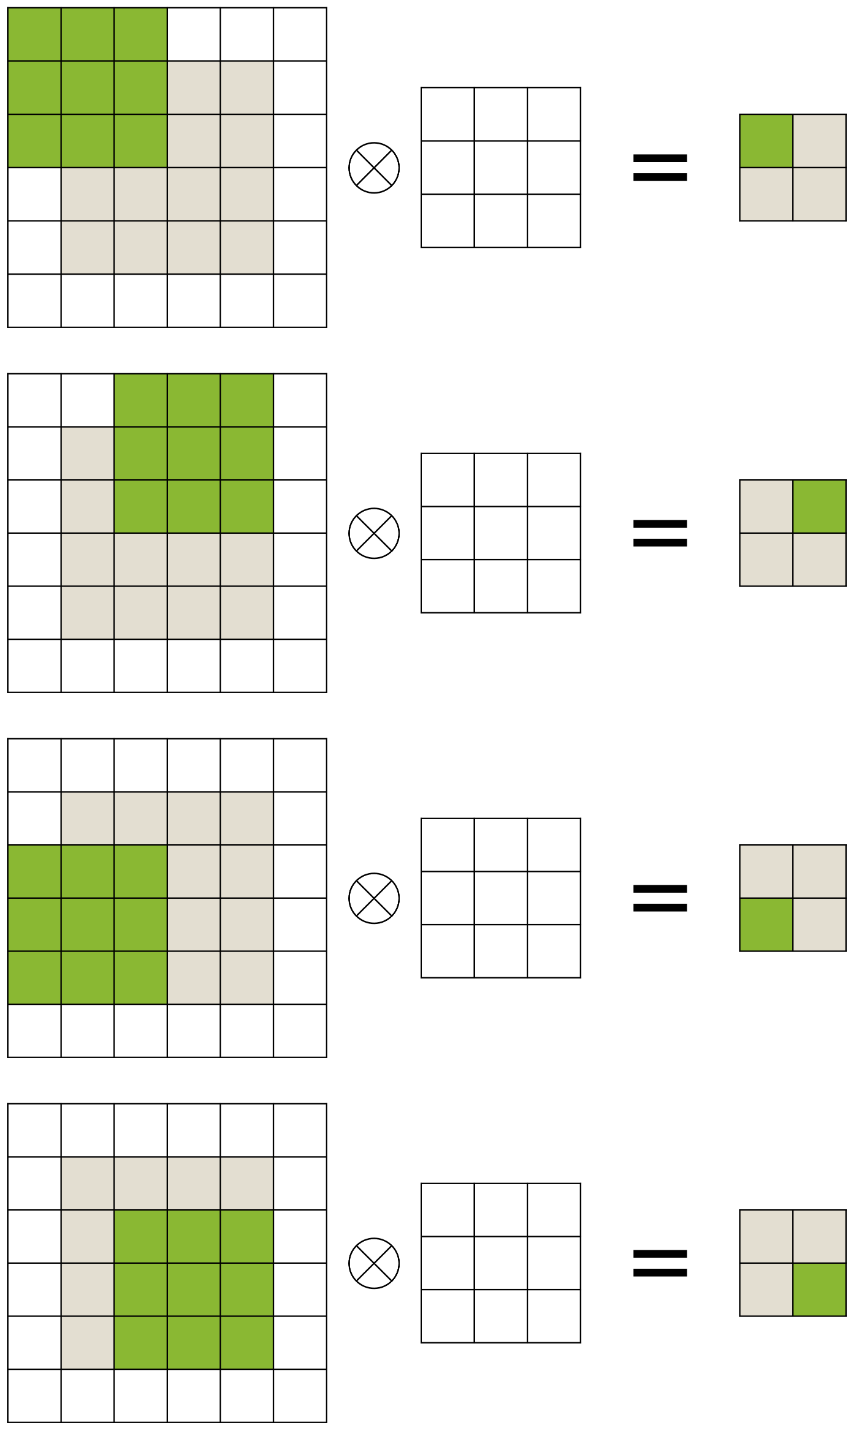

### 스트라이드도입 시 합성곱 계층의 입출력 크기
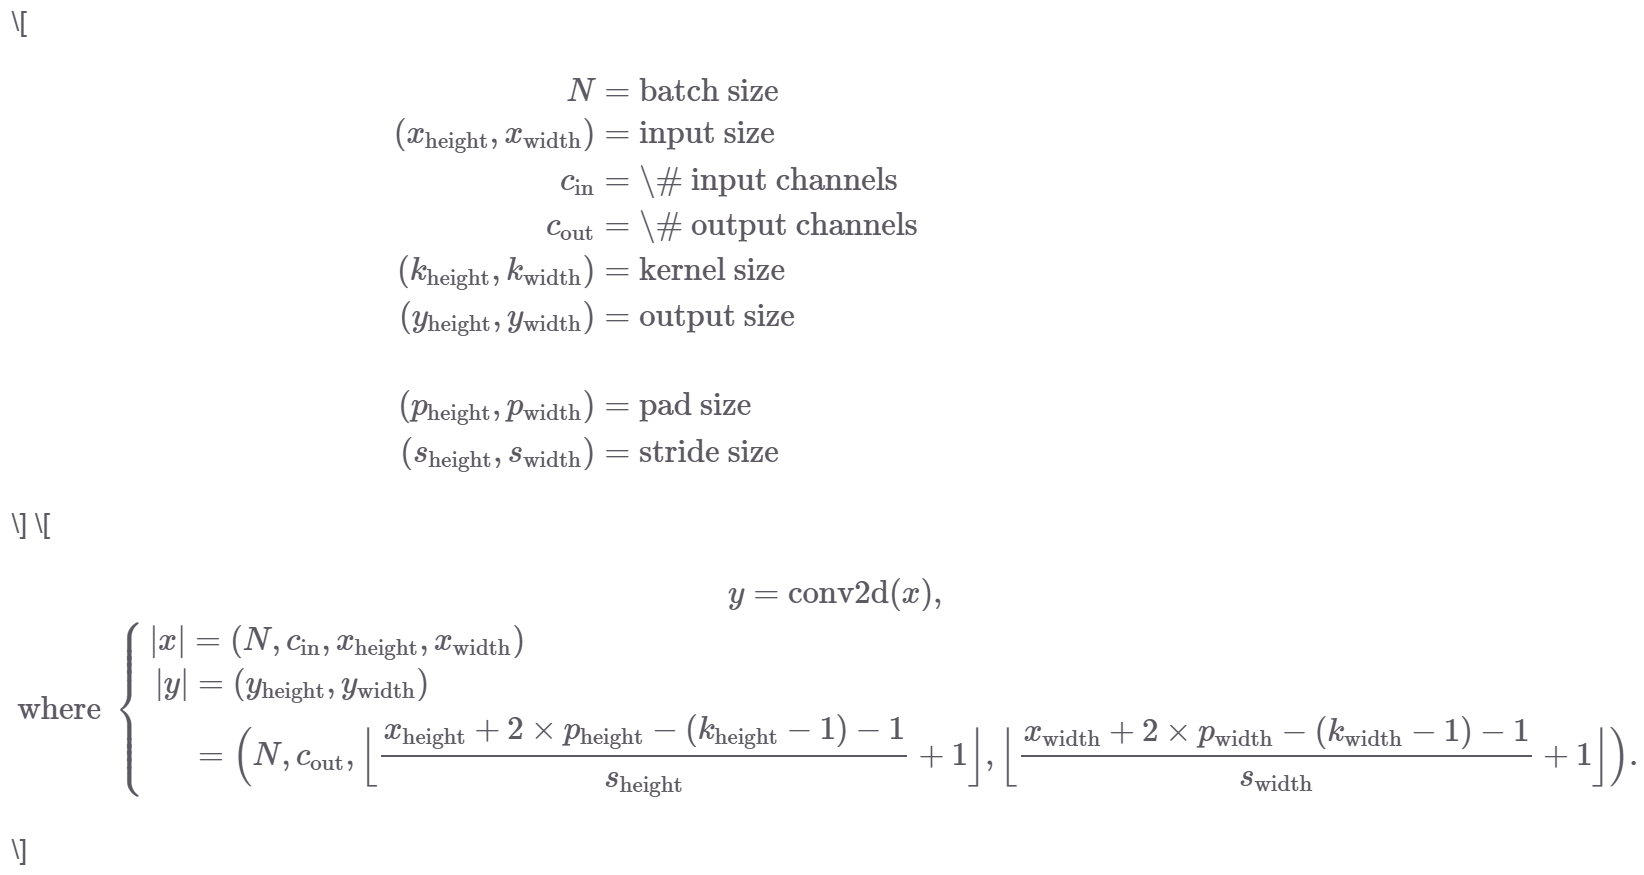

### 합성곱 신경망 설게 예제
- 심층신경망의 서브 모듈
  - 합성곱 계층 * 2
  - 비선형 활성화 함수(ReLU) * 2
  - 배치 정규화 계층 * 2
  - 스트라이드(2x2) 혹은 맥스 풀링(2x2)으로 출력 크기를 반으로 줄임

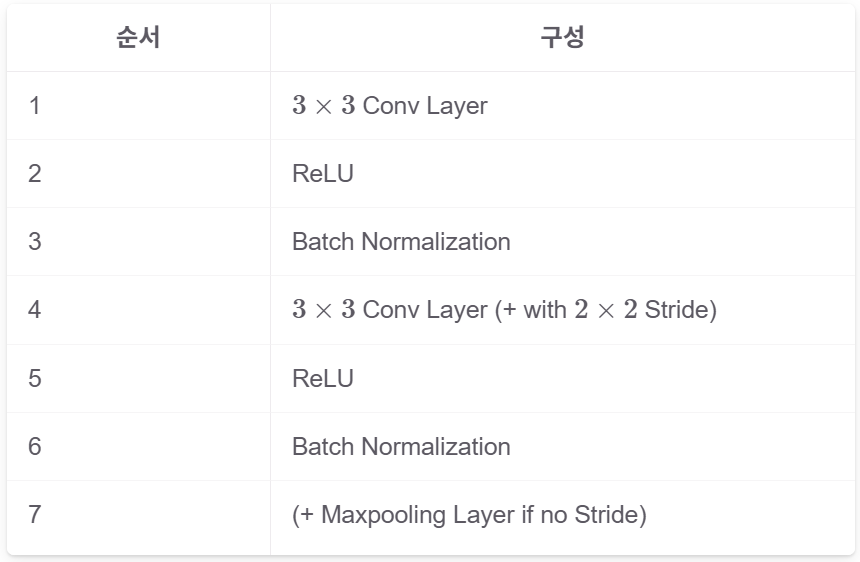
- 이런 서브 모듈을 아래 그림과 같이 CNN 블록으로 표현하기도 함

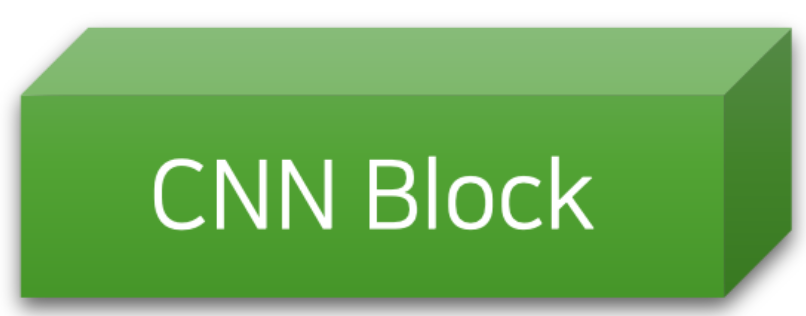

### CNN 블록을 확용한 신경망 설계
- 이미지를 |C|개의 클래스 중 하나로 분류하는 문제
- (N, C, H, W) 크기의 이미지 미니배치를 입력
  - H $\cdot$ W 크기의 C개 채널을 가진 N개의 이미지
- (N, |C|) 크기의 결과 행렬 출력

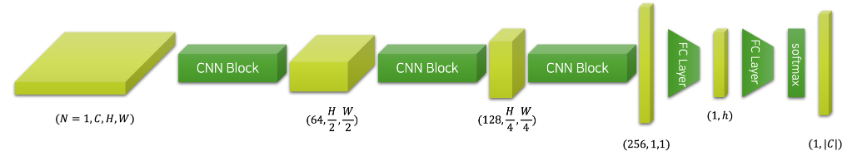
- N=1 하나의 샘플
- C: 입력 채널 수(컬러: 3, 흑백: 1)
- CNN 블록을 지날 때마다 텐서의 크기가 반으로 줄어들어, 최종적으로 H = 1, W = 1이 됨
- CNN 블록을 종료하고 선형 계층을 통과한 후, 소프트맥스 활성화 함수로 분류 결과를 출력